# 1) Cài đặt môi trường

In [2]:
# ==============================================
# 1. CÀI ĐẶT MÔI TRƯỜNG & TẢI DỮ LIỆU
# ==============================================
import os, zipfile, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# --- Tự động tìm dataset (Kaggle input) hoặc tải từ GDrive ---
KAGGLE_INPUT_DIR = "/kaggle/input"
LOCAL_EXTRACT_DIR = "/kaggle/working/dataset_unzipped" if os.path.exists("/kaggle") else "/content/dataset_unzipped"
ZIP_FILENAME = "Harvesting_Dataset.zip"

zip_path = None
if os.path.exists(KAGGLE_INPUT_DIR):
    for root, dirs, files in os.walk(KAGGLE_INPUT_DIR):
        if ZIP_FILENAME in files:
            zip_path = os.path.join(root, ZIP_FILENAME)
            break

if zip_path is None:
    import gdown
    DRIVE_FILE_ID = "11OP0vbp2vJZxhkD0K4DAFyNSHtOASyr3"  # ID file của bạn
    print("⏳ Tải file zip từ Google Drive...")
    url = f"https://drive.google.com/uc?id={DRIVE_FILE_ID}"
    zip_path = "/kaggle/working/temp.zip" if os.path.exists("/kaggle") else "/content/temp.zip"
    gdown.download(url, zip_path, quiet=False)
else:
    print(f"✅ Tìm thấy file zip: {zip_path}")

if not os.path.exists(LOCAL_EXTRACT_DIR):
    print("⏳ Giải nén dữ liệu...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    if "temp.zip" in zip_path:
        os.remove(zip_path)
    print("✅ Giải nén xong!")
else:
    print("✅ Dữ liệu đã được giải nén.")

# Tìm đúng folder chứa Cut/Keep
target_folders = ["Cut", "Keep"]
DATA_DIR = LOCAL_EXTRACT_DIR
found = False
for root, dirs, files in os.walk(LOCAL_EXTRACT_DIR):
    if any(f in dirs for f in target_folders):
        DATA_DIR = root
        found = True
        break
print(f"📂 DATA_DIR: {DATA_DIR}")
print("Subfolders:", os.listdir(DATA_DIR))

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
⏳ Tải file zip từ Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=11OP0vbp2vJZxhkD0K4DAFyNSHtOASyr3
From (redirected): https://drive.google.com/uc?id=11OP0vbp2vJZxhkD0K4DAFyNSHtOASyr3&confirm=t&uuid=08fa1de2-0c08-4607-ae43-d7dff0d18554
To: /kaggle/working/temp.zip

  0%|          | 0.00/4.84G [00:00<?, ?B/s]
  0%|          | 16.8M/4.84G [00:00<00:29, 165MB/s]
  1%|          | 46.7M/4.84G [00:00<00:19, 242MB/s]
  2%|▏         | 78.1M/4.84G [00:00<00:17, 273MB/s]
  2%|▏         | 109M/4.84G [00:00<00:16, 284MB/s] 
  3%|▎         | 137M/4.84G [00:00<00:16, 280MB/s]
  3%|▎         | 169M/4.84G [00:00<00:16, 290MB/s]
  4%|▍         | 200M/4.84G [00:00<00:15, 294MB/s]
  5%|▍         | 230M/4.84G [00:00<00:15, 290MB/s]
  5%|▌         | 259M/4.84G [00:00<00:16, 285MB/s]
  6%|▌         | 288M/4.84G [00:01<00:16, 281MB/s]
  7%|▋         | 316M/4.84G [00:01<00:16, 269MB/s]
  7%|▋         | 346M/4.84G [00:01<00:16, 276MB/s]
  8%|▊         | 374M/4.84G [00:01<00:16, 269MB/s]
  8%|▊         | 401M/4.84

⏳ Giải nén dữ liệu...
✅ Giải nén xong!
📂 DATA_DIR: /kaggle/working/dataset_unzipped/Harvesting_Dataset
Subfolders: ['Keep', 'Cut']


# 2) Tiền xử lý dữ liệu

In [3]:
# ==============================================
# 2. TIỀN XỬ LÝ DỮ LIỆU (ImageDataGenerator)
# ==============================================
IMG_SIZE = (224, 224)          # ResNet50 input size
BATCH = 32

train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest',
    validation_split=0.30
)

no_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.30
)

print(f"\n--- Loading Data from: {DATA_DIR} ---")
train_it = train_aug.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=SEED
)

temp_it = no_aug.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=SEED
)

# Chia val/test (shuffle)
temp_paths = np.array(temp_it.filepaths)
temp_labels = np.array(temp_it.classes)
indices = np.arange(len(temp_paths))
np.random.shuffle(indices)
temp_paths = temp_paths[indices]
temp_labels = temp_labels[indices]
mid = len(temp_paths) // 2
val_paths, val_labels = temp_paths[:mid], temp_labels[:mid]
test_paths, test_labels = temp_paths[mid:], temp_labels[mid:]

print("-" * 30)
print(f"Train size: {train_it.samples}")
print(f"Val size  : {len(val_paths)} (Class 0: {np.sum(val_labels==0)}, Class 1: {np.sum(val_labels==1)})")
print(f"Test size : {len(test_paths)} (Class 0: {np.sum(test_labels==0)}, Class 1: {np.sum(test_labels==1)})")
print("-" * 30)

# Class weights
train_labels_cls = train_it.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_cls),
    y=train_labels_cls
)
class_weights_dict = dict(enumerate(class_weights))
print(f"⚖️ Class Weights: {class_weights_dict}")

# Tạo tf.data cho val/test
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return img, label

def make_ds(paths, labels, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds = make_ds(val_paths, val_labels)
test_ds = make_ds(test_paths, test_labels)
print("✅ Tiền xử lý hoàn tất.")


--- Loading Data from: /kaggle/working/dataset_unzipped/Harvesting_Dataset ---
Found 1881 images belonging to 2 classes.
Found 804 images belonging to 2 classes.
------------------------------
Train size: 1881
Val size  : 402 (Class 0: 177, Class 1: 225)
Test size : 402 (Class 0: 165, Class 1: 237)
------------------------------
⚖️ Class Weights: {0: np.float64(1.1741573033707866), 1: np.float64(0.8708333333333333)}
✅ Tiền xử lý hoàn tất.


I0000 00:00:1778331461.208115      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778331461.214502      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# 3) Huấn luyện mô hình

In [4]:
# ==============================================
# 3. XÂY DỰNG MÔ HÌNH ResNet50
# ==============================================
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import ResNet50

def build_model(stage=1):
    """
    stage=1: chỉ train head (base frozen)
    stage=2: fine-tune toàn bộ (base unfrozen, BN frozen)
    """
    base = ResNet50(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
    
    if stage == 1:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False   # giữ nguyên mean/var của BN

    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)  # BN ở chế độ inference
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model(stage=1)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,120,705 (92.01 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [5]:
# ==============================================
# 4. HUẤN LUYỆN GIAI ĐOẠN 1 (WARM-UP)
# ==============================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='acc'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

early_stop_1 = callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr_1 = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)
model_ckpt_1 = callbacks.ModelCheckpoint(
    '/kaggle/working/best_model_stage1.h5' if os.path.exists("/kaggle") else '/content/best_model_stage1.h5',
    monitor='val_auc', mode='max', save_best_only=True, verbose=1
)

EPOCHS = 30
print("\n🚀 Giai đoạn 1: Huấn luyện head...")
history_stage1 = model.fit(
    train_it,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop_1, reduce_lr_1, model_ckpt_1],
    class_weight=class_weights_dict,
    verbose=1
)

# Load best model của stage 1
model.load_weights(model_ckpt_1.filepath)


🚀 Giai đoạn 1: Huấn luyện head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1778331479.401138     154 service.cc:152] XLA service 0x7c9c3804fd10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778331479.401188     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778331479.401196     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778331481.557055     154 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/59 ━━━━━━━━━━━━━━━━━━━━ 15:49 16s/step - acc: 0.5000 - auc: 0.3730 - loss: 0.8743

...

59/59 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - acc: 0.5361 - auc: 0.5320 - loss: 0.8676 - val_acc: 0.5597 - val_auc: 0.6510 - val_loss: 0.9534 - learning_rate: 0.0010
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5797 - auc: 0.6100 - loss: 0.7423
Epoch 2: val_auc did not improve from 0.65101
59/59 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.5793 - auc: 0.6094 - loss: 0.7428 - val_acc: 0.5697 - val_auc: 0.5897 - val_loss: 0.7081 - learning_rate: 0.0010
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5844 - auc: 0.6012 - loss: 0.7454
Epoch 3: val_auc did not improve from 0.65101
59/59 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.5841 - auc: 0.6010 - loss: 0.7455 - val_acc: 0.5871 - val_auc: 0.6068 - val_loss: 0.7060 - learning_rate: 0.0010
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5726 - auc: 0.6128 - loss: 0.7160
Epoch 4: val_auc did not improve from 0.65101
59/59 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.5725 - auc: 0.6124 - loss: 0.7163 - val_acc: 0.4851

59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.5924 - auc: 0.6068 - loss: 0.7043 - val_acc: 0.5721 - val_auc: 0.6570 - val_loss: 0.7019 - learning_rate: 0.0010
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5560 - auc: 0.5919 - loss: 0.7138
Epoch 9: val_auc did not improve from 0.65700
59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.5563 - auc: 0.5920 - loss: 0.7138 - val_acc: 0.6070 - val_auc: 0.6417 - val_loss: 0.6967 - learning_rate: 0.0010
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5844 - auc: 0.6065 - loss: 0.7021
Epoch 10: val_auc improved from 0.65700 to 0.66128, saving model to /kaggle/working/best_model_stage1.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.5843 - auc: 0.6063 - loss: 0.7022 - val_acc: 0.5796 - val_auc: 0.6613 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 11/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5860 - auc: 0.6145 - loss: 0.6982
Epoch 11: val_auc improved from 0.66128 to 0.66540, saving model to /kaggle/working/best_model_stage1.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.5859 - auc: 0.6144 - loss: 0.6983 - val_acc: 0.6244 - val_auc: 0.6654 - val_loss: 0.6780 - learning_rate: 0.0010
Epoch 12/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5886 - auc: 0.6316 - loss: 0.6942
Epoch 12: val_auc did not improve from 0.66540
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.5887 - auc: 0.6316 - loss: 0.6942 - val_acc: 0.6244 - val_auc: 0.6583 - val_loss: 0.6812 - learning_rate: 0.0010
Epoch 13/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5821 - auc: 0.5989 - loss: 0.6971
Epoch 13: val_auc did not improve from 0.66540
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.5822 - auc: 0.5991 - loss: 0.6970 - val_acc: 0.5299 - val_auc: 0.6440 - val_loss: 0.7128 - learning_rate: 0.0010
Epoch 14/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5876 - auc: 0.6231 - loss: 0.6973
Epoch 14: val_auc did not improve from 0.66540
59/59 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - acc: 0.5876 - auc: 0.6231 - loss: 0.6972 - val_acc: 

59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.5895 - auc: 0.6229 - loss: 0.6917 - val_acc: 0.6393 - val_auc: 0.6856 - val_loss: 0.6763 - learning_rate: 0.0010
Epoch 17/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5896 - auc: 0.6277 - loss: 0.6919
Epoch 17: val_auc did not improve from 0.68562
59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.5896 - auc: 0.6276 - loss: 0.6920 - val_acc: 0.6144 - val_auc: 0.6655 - val_loss: 0.6852 - learning_rate: 0.0010
Epoch 18/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5711 - auc: 0.5820 - loss: 0.7171
Epoch 18: val_auc did not improve from 0.68562
59/59 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - acc: 0.5712 - auc: 0.5823 - loss: 0.7169 - val_acc: 0.6219 - val_auc: 0.6538 - val_loss: 0.6831 - learning_rate: 0.0010
Epoch 19/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5755 - auc: 0.6273 - loss: 0.6894
Epoch 19: val_auc did not improve from 0.68562
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.5758 - auc: 0.6273 - loss: 0.6894 - val_acc: 

In [7]:
# ==============================================
# 5. HUẤN LUYỆN GIAI ĐOẠN 2 (FINE-TUNE)
# ==============================================
# Xây dựng lại model với base unfrozen (stage=2)
model_ft = build_model(stage=2)
# Copy trọng số từ stage 1 sang
model_ft.set_weights(model.get_weights())

model_ft.compile(
    optimizer=optimizers.SGD(learning_rate=0.0001, momentum=0.9),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='acc'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

early_stop_2 = callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr_2 = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)
model_ckpt_2 = callbacks.ModelCheckpoint(
    '/kaggle/working/best_model_stage2.h5' if os.path.exists("/kaggle") else '/content/best_model_stage2.h5',
    monitor='val_auc', mode='max', save_best_only=True, verbose=1
)

EPOCHS_FT = 100
print("\n🚀 Giai đoạn 2: Fine-tuning toàn bộ mạng...")
history_stage2 = model_ft.fit(
    train_it,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=[early_stop_2, reduce_lr_2, model_ckpt_2],
    class_weight=class_weights_dict,
    verbose=1
)

# Load best model sau fine-tune
model_ft.load_weights(model_ckpt_2.filepath)

 70%|███████   | 3.39G/4.84G [52:00<22:10, 1.09MB/s]



🚀 Giai đoạn 2: Fine-tuning toàn bộ mạng...
Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5353 - auc: 0.5268 - loss: 0.7090
Epoch 1: val_auc improved from -inf to 0.50000, saving model to /kaggle/working/best_model_stage2.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - acc: 0.5353 - auc: 0.5269 - loss: 0.7091 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 15.9309 - learning_rate: 1.0000e-04
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5594 - auc: 0.5788 - loss: 0.7088
Epoch 2: val_auc did not improve from 0.50000
59/59 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.5594 - auc: 0.5788 - loss: 0.7088 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 10.5584 - learning_rate: 1.0000e-04
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5711 - auc: 0.5905 - loss: 0.7023
Epoch 3: val_auc did not improve from 0.50000
59/59 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - acc: 0.5710 - auc: 0.5903 - loss: 0.7024 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 8.7660 - learning_rate: 1.0000e-04
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5498 - auc: 0.5559 - loss: 0.7159
Epoch 4: val_auc improved from 0.50000 to 0.65707, saving model to /kaggle/working/best_model_stage2.h5


59/59 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - acc: 0.5500 - auc: 0.5561 - loss: 0.7158 - val_acc: 0.4403 - val_auc: 0.6571 - val_loss: 1.1597 - learning_rate: 1.0000e-04
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5772 - auc: 0.6162 - loss: 0.6927
Epoch 5: val_auc did not improve from 0.65707
59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.5773 - auc: 0.6161 - loss: 0.6928 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 4.8732 - learning_rate: 1.0000e-04
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5832 - auc: 0.6068 - loss: 0.6974
Epoch 6: val_auc did not improve from 0.65707
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.5831 - auc: 0.6067 - loss: 0.6975 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 23.7666 - learning_rate: 1.0000e-04
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5902 - auc: 0.6326 - loss: 0.6952
Epoch 7: val_auc did not improve from 0.65707
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.5902 - auc: 0.6324 - loss: 0.6952 -

59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.6415 - auc: 0.6936 - loss: 0.6614 - val_acc: 0.4602 - val_auc: 0.7995 - val_loss: 0.9040 - learning_rate: 2.5000e-05
Epoch 16/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6402 - auc: 0.6912 - loss: 0.6561
Epoch 16: val_auc did not improve from 0.79949
59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.6402 - auc: 0.6912 - loss: 0.6562 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 31.8933 - learning_rate: 2.5000e-05
Epoch 17/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6272 - auc: 0.6858 - loss: 0.6571
Epoch 17: val_auc did not improve from 0.79949
59/59 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.6274 - auc: 0.6858 - loss: 0.6572 - val_acc: 0.5597 - val_auc: 0.5000 - val_loss: 5.7583 - learning_rate: 2.5000e-05
Epoch 18/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6428 - auc: 0.6951 - loss: 0.6529
Epoch 18: val_auc did not improve from 0.79949
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - acc: 0.6427 - auc: 0.6950 - loss: 0.

59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.6575 - auc: 0.7191 - loss: 0.6422 - val_acc: 0.6891 - val_auc: 0.8090 - val_loss: 0.6215 - learning_rate: 1.2500e-05
Epoch 24/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6778 - auc: 0.7383 - loss: 0.6351
Epoch 24: val_auc did not improve from 0.80900
59/59 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - acc: 0.6775 - auc: 0.7380 - loss: 0.6352 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 9.8152 - learning_rate: 1.2500e-05
Epoch 25/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6505 - auc: 0.7048 - loss: 0.6465
Epoch 25: val_auc did not improve from 0.80900
59/59 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - acc: 0.6504 - auc: 0.7048 - loss: 0.6465 - val_acc: 0.4403 - val_auc: 0.5000 - val_loss: 44.1679 - learning_rate: 1.2500e-05
Epoch 26/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.6620 - auc: 0.7110 - loss: 0.6509
Epoch 26: val_auc did not improve from 0.80900
59/59 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - acc: 0.6619 - auc: 0.7110 - loss: 0.

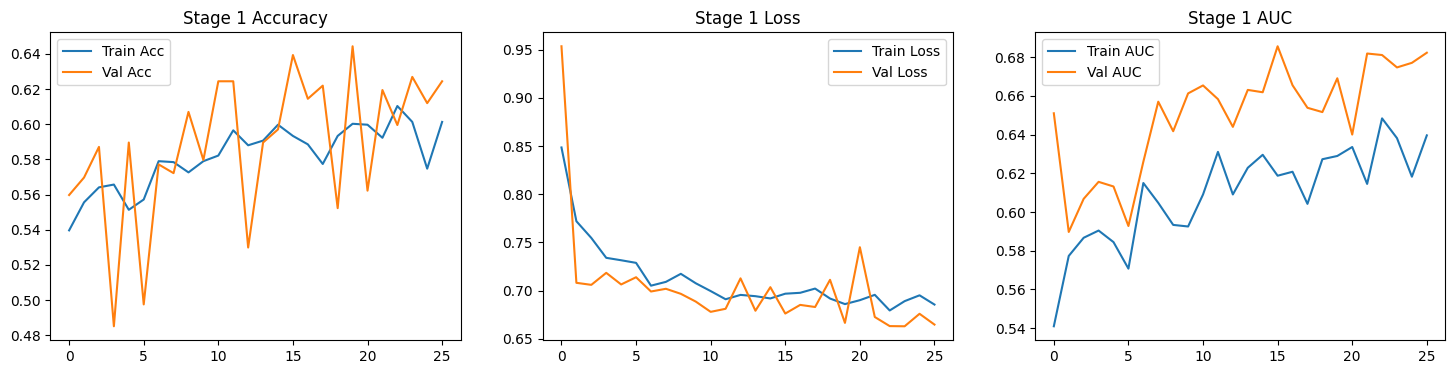

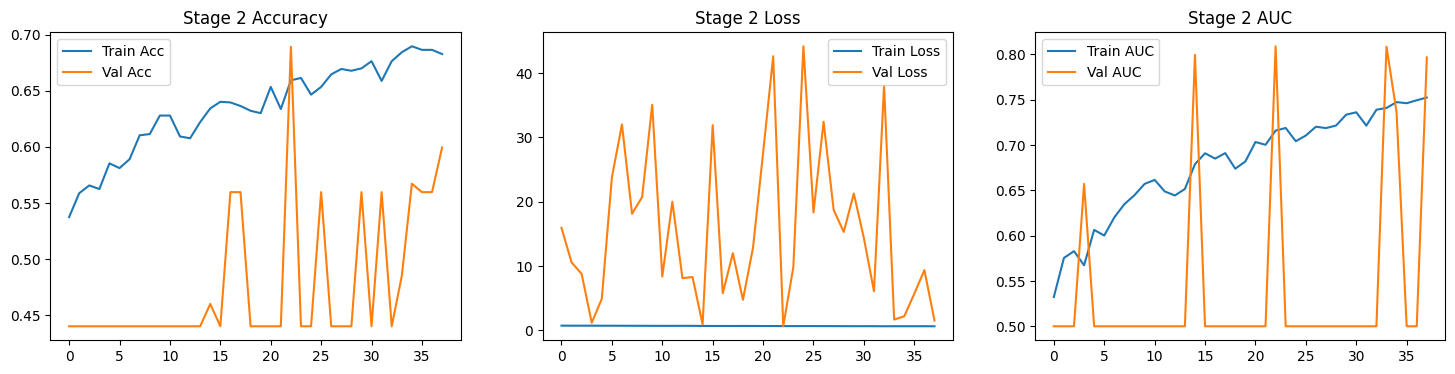

In [8]:
# ==============================================
# 6. TRỰC QUAN HOÁ LỊCH SỬ HUẤN LUYỆN
# ==============================================
def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(18,4))
    axes[0].plot(history.history['acc'], label='Train Acc')
    axes[0].plot(history.history['val_acc'], label='Val Acc')
    axes[0].set_title(f'{title} Accuracy')
    axes[0].legend()
    
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} Loss')
    axes[1].legend()
    
    axes[2].plot(history.history['auc'], label='Train AUC')
    axes[2].plot(history.history['val_auc'], label='Val AUC')
    axes[2].set_title(f'{title} AUC')
    axes[2].legend()
    plt.show()

plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")


--- Đang tìm Threshold tối ưu trên tập Valid ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 664ms/step

🏆 BEST THRESHOLD (Validation):
{'thr': np.float64(0.15000000000000002), 'precision': np.float64(0.6656151419537363), 'recall': np.float64(0.9377777777736099), 'f1': np.float64(0.778597785489393), 'acc': np.float64(0.7014925373116878), 'specificity': np.float64(0.40112994350055864)}

--- Đánh giá trên tập TEST ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step
Chosen Threshold: 0.1500
Test Accuracy   : 0.7239
Test F1-Score   : 0.7963
Test Precision  : 0.7045
Test Recall     : 0.9156
Test Specificity: 0.4485


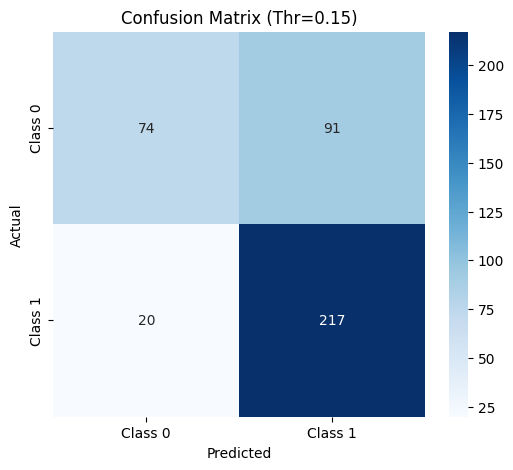

In [9]:
# ==============================================
# 7. TÌM NGƯỠNG TỐI ƯU & ĐÁNH GIÁ TEST
# ==============================================
def metrics_at_thr(y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    tp = np.sum((y_hat == 1) & (y_true == 1))
    tn = np.sum((y_hat == 0) & (y_true == 0))
    fp = np.sum((y_hat == 1) & (y_true == 0))
    fn = np.sum((y_hat == 0) & (y_true == 1))
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    acc       = (tp + tn) / (tp + tn + fp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)
    return precision, recall, f1, acc, specificity

print("\n--- Đang tìm Threshold tối ưu trên tập Valid ---")
val_probs = model_ft.predict(val_ds, verbose=1).ravel()
val_y = val_labels.astype(int)

best = None
for t in np.linspace(0.1, 0.9, 81):
    prec, rec, f1, acc, spe = metrics_at_thr(val_y, val_probs, t)
    if best is None or f1 > best["f1"]:
        best = {"thr": t, "precision": prec, "recall": rec, "f1": f1, "acc": acc, "specificity": spe}

print("\n🏆 BEST THRESHOLD (Validation):")
print(best)

print("\n--- Đánh giá trên tập TEST ---")
test_probs = model_ft.predict(test_ds, verbose=1).ravel()
test_y = test_labels.astype(int)

thr = best["thr"]
prec, rec, f1, acc, spe = metrics_at_thr(test_y, test_probs, thr)

print(f"Chosen Threshold: {thr:.4f}")
print(f"Test Accuracy   : {acc:.4f}")
print(f"Test F1-Score   : {f1:.4f}")
print(f"Test Precision  : {prec:.4f}")
print(f"Test Recall     : {rec:.4f}")
print(f"Test Specificity: {spe:.4f}")

# Confusion Matrix
y_hat_test = (test_probs >= thr).astype(int)
cm = confusion_matrix(test_y, y_hat_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Thr={thr:.2f})')
plt.show()

In [10]:
# ==============================================
# 8. LƯU MÔ HÌNH CUỐI CÙNG
# ==============================================
SAVE_PATH = '/kaggle/working/resnet50_final.h5' if os.path.exists("/kaggle") else '/content/resnet50_final.h5'
model_ft.save(SAVE_PATH)
print(f"✅ Model đã lưu tại: {SAVE_PATH}")

✅ Model đã lưu tại: /kaggle/working/resnet50_final.h5
